In [1]:
import sys

sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

large_data_dir = gf_utils.large_data_dir

# Assign alleles for cell line gapfills

In [2]:
manifest = pd.read_csv('../../1_figure_CL_proof_of_concept/data/manifest_gapfill_1plex.tsv', sep='\t')

manifest.loc[manifest['gap_probe_sequence'].isna(), 'name'] = manifest.loc[manifest['gap_probe_sequence'].isna(),'name'] + ' 0bp' ## annotate non-variant probes as 0bp
manifest['type'] = 'gapfill'
manifest.loc[manifest['name'].str.contains('0bp'),'type'] = '0bp_control'


In [3]:
gf_dir = large_data_dir + 'gf_CL3_HB_Betaine/BC1_giftwrap/'
adata_path = large_data_dir + 'CL3_HB_Betaine_0bp_genotype_GF.h5ad'

read_threshold = 10

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold=read_threshold, min_percent_supporting=0.9, adata_path=adata_path)
probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start']], left_on='probe_idx',right_index=True, how='left')

## get ground truth cell line genotypes
mutations = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',index_col=0)
mutations_pivot = mutations.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
mutations_pivot = mutations_pivot.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})
mutations_pivot = mutations_pivot.drop('HTT c.8157G>A') ### drop because we are not confident in genotyping

## subset probe reads to non-heterozygous
probe_reads = probe_reads.merge(mutations_pivot.reset_index().melt(id_vars='name', var_name='cell_type', value_name='genotype'), on = ['name','cell_type'], how='left')
probe_reads = probe_reads.loc[probe_reads['genotype'].isin(['wt','mutated'])].reset_index(drop=True).copy()
probe_reads.loc[probe_reads['genotype'] == 'wt','expected_gapfill'] = probe_reads.loc[probe_reads['genotype'] == 'wt','gapfill_from_transcriptome']
probe_reads.loc[probe_reads['genotype'] == 'mutated','expected_gapfill'] = probe_reads.loc[probe_reads['genotype'] == 'mutated','gap_probe_sequence']


9362534 UMIs found
Filtering probe reads based on read threshold (10) and min percent supporting (0.9), 7733290 UMIs remaining (82.60%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 6568060 UMIs remaining (70.15%)


In [4]:
### filter to targets with fully annotated wt (gapfill_from_transcriptome) and mutated (gap_probe_sequence) genotypes, and no 'N's in either sequence
to_assign = probe_reads.dropna(subset=['gapfill_from_transcriptome','gap_probe_sequence'], how='any').copy()
to_assign = to_assign.loc[~((to_assign['gapfill_from_transcriptome'].str.contains('N')) | to_assign['gap_probe_sequence'].str.contains('N'))].copy()

In [5]:
def get_gapfill_likelihoods(gapfill,error_rate_dicts,alleles):
    likelihoods = gf_utils.get_likelihoods_of_true_allele(gapfill, error_rate_dicts)
    likelihood_list = {}
    for allele in alleles:
        if allele in likelihoods:
            likelihood_list[allele] = likelihoods[allele]
        else:
            likelihood_list[allele] = 10e-10
    return likelihood_list
error_rate_dir = '../../3_figure_FFPE/code/00_probabilistic_genotype_assignment/data/error_rate_dicts'
error_rate_dicts = gf_utils.get_error_rate_dicts(error_rate_dir)

In [6]:
# deduplicate and compute likelihoods for each unique combination of gapfill

unique_combos = to_assign[['gapfill', 'gapfill_from_transcriptome', 'gap_probe_sequence']].drop_duplicates()

likelihood_cache = {}
for _, row in unique_combos.iterrows():
    key = (row['gapfill'], row['gapfill_from_transcriptome'], row['gap_probe_sequence'])
    likelihoods = get_gapfill_likelihoods(key[0], error_rate_dicts, [key[1], key[2]])
    likelihood_cache[key] = (likelihoods[key[1]], likelihoods[key[2]])

# map back to full df
keys = list(zip(to_assign['gapfill'], to_assign['gapfill_from_transcriptome'], to_assign['gap_probe_sequence']))
results = pd.DataFrame(
    [likelihood_cache[k] for k in keys],
    columns=['wt', 'mutated'],
    index=to_assign.index,
)

In [7]:
results['p_wt'] = results['wt'] / (results['wt'] + results['mutated'])
results['p_mutated'] = results['mutated'] / (results['wt'] + results['mutated'])

to_assign[['p_wt', 'p_mutated']] = results[['p_wt', 'p_mutated']]

to_assign.loc[to_assign['genotype'] == 'wt','p_correct'] = to_assign.loc[to_assign['genotype'] == 'wt','p_wt']
to_assign.loc[to_assign['genotype'] == 'mutated','p_correct'] = to_assign.loc[to_assign['genotype'] == 'mutated','p_mutated']

In [8]:
GBM_props = pd.read_csv('../output/GBM_gapfill_assignment_metrics.csv', index_col = 0)

In [9]:
### organize data for plotting

assignment_threshold = 0.9

filtered_pre = to_assign.loc[(to_assign['gapfill'] != to_assign['gapfill_from_transcriptome']) & (to_assign['gapfill'] != to_assign['gap_probe_sequence'])]
n_filtered_pre = len(filtered_pre)
n_still_unassigned = len(filtered_pre.loc[(filtered_pre['p_correct'] < assignment_threshold) & (filtered_pre['p_correct'] > (1-assignment_threshold))])
n_rescued_correct = len(filtered_pre.loc[filtered_pre['p_correct'] >= assignment_threshold])
n_rescued_incorrect = len(filtered_pre.loc[filtered_pre['p_correct'] <= (1-assignment_threshold)])

plot_data_counts = pd.DataFrame({
    'assigned correct':   [0, n_rescued_correct],
    'assigned incorrect': [0, n_rescued_incorrect],
    'unassigned':         [n_filtered_pre, n_still_unassigned],
}, index=['cl_pre', 'cl_post'])

plot_data = plot_data_counts / len(to_assign)

## combine dataframes to make 1 plot of stacked bars
# From plot_data
df1 = plot_data.copy()
df1['assigned'] = 0.0
df1 = df1[['assigned correct', 'assigned incorrect', 'assigned', 'unassigned']]

# From GBM_props
df2 = pd.DataFrame({
    'assigned correct': 0.0,
    'assigned incorrect': 0.0,
    'assigned': [0.0, GBM_props.loc[GBM_props['assignment_status'] == 'assigned_post', 'proportion'].values[0]],
    'unassigned': [GBM_props.loc[GBM_props['assignment_status'] == 'unassigned_pre', 'proportion'].values[0],
                   GBM_props.loc[GBM_props['assignment_status'] == 'unassigned_post', 'proportion'].values[0]]
}, index=['GBM_pre', 'GBM_post'])

df_final = pd.concat([df1, df2])


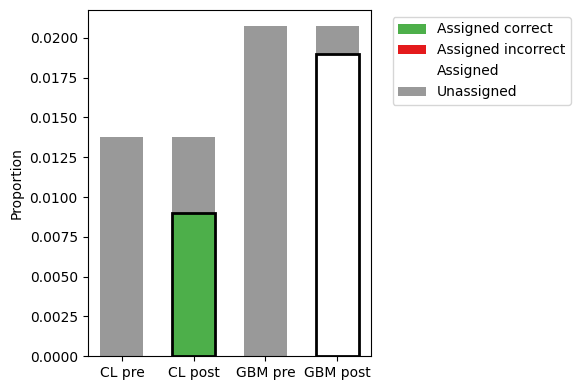

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(df_final))
bar_width = 0.6

# Stack order: assigned correct, assigned incorrect, assigned, unassigned
bottom = np.zeros(len(df_final))

# Assigned correct - green
bars_correct = ax.bar(x, df_final['assigned correct'], bar_width, bottom=bottom, color='#4daf4a', label='Assigned correct')
bottom += df_final['assigned correct'].values

# Assigned incorrect - red
bars_incorrect = ax.bar(x, df_final['assigned incorrect'], bar_width, bottom=bottom, color='#e41a1c', label='Assigned incorrect')
bottom += df_final['assigned incorrect'].values

# Assigned (GBM) - white
bars_assigned = ax.bar(x, df_final['assigned'], bar_width, bottom=bottom, color='white', label='Assigned')
bottom += df_final['assigned'].values

# Unassigned - grey
bars_unassigned = ax.bar(x, df_final['unassigned'], bar_width, bottom=bottom, color='#999999', label='Unassigned')

# Bold black border around all assigned segments (correct + incorrect + assigned)
for i in range(len(df_final)):
    assigned_total = df_final['assigned correct'].iloc[i] + df_final['assigned incorrect'].iloc[i] + df_final['assigned'].iloc[i]
    if assigned_total > 0:
        rect = mpatches.FancyBboxPatch(
            (x[i] - bar_width / 2, 0),
            bar_width, assigned_total,
            boxstyle="square,pad=0",
            linewidth=2, edgecolor='black', facecolor='none',
            zorder=5
        )
        ax.add_patch(rect)

ax.set_xticks(x)
ax.set_xticklabels(['CL pre', 'CL post', 'GBM pre', 'GBM post'])
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('../plots/gapfill_assignment_outside_set.pdf')

In [11]:
### compare rate of correct assignment from model to direct observation (cell lines only)
print('model:', n_rescued_correct / (n_rescued_correct + n_rescued_incorrect))

n_correct_pre = len(to_assign.loc[to_assign['gapfill'] == to_assign['expected_gapfill']])
n_assigned_pre = len(to_assign.loc[(to_assign['gapfill'] == to_assign['gapfill_from_transcriptome']) | (to_assign['gapfill'] == to_assign['gap_probe_sequence'])])

print('observed:',n_correct_pre / n_assigned_pre)

model: 0.9961474036850921
observed: 0.9979419437153096
